<a href="https://colab.research.google.com/github/SANGHATI23/sam-brats-robustness-audit/blob/main/02_MedReasoner_Blinded_VLM_Failure_Recognition_Qwen25VL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Runtime / GPU check
import os, sys, platform
import torch

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required. Select an A100 runtime and rerun.")

print("GPU:", torch.cuda.get_device_name(0))
props = torch.cuda.get_device_properties(0)
print(f"GPU memory: {props.total_memory / 1024**3:.1f} GB")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 79.3 GB


In [2]:
# CELL 2 — Install VLM + evaluation dependencies
import subprocess, sys

packages = [
    "transformers>=4.49.0,<5",
    "accelerate>=1.2.0",
    "qwen-vl-utils>=0.0.10",
    "scikit-learn>=1.5",
    "scipy>=1.13",
    "pandas>=2.2",
    "numpy>=1.26",
    "pillow>=10",
    "matplotlib>=3.8",
    "tqdm>=4.66",
]

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", *packages],
    check=True
)

print("Dependencies installed.")

Dependencies installed.


In [3]:
# CELL 3 — Imports, seeds, configuration
import os, re, json, time, random, math, gc
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display

import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from scipy.stats import spearmanr

from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
EXPERIMENT_ID = "02_blinded_failure_recognition_qwen25vl7b"
PROMPT_VERSION = "v1.0"

OVERWRITE_EXISTING = False
MAX_CASES = None

MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 1024 * 28 * 28
MAX_NEW_TOKENS = 180

DOMAIN_TARGET = {
    "brain_mri": {
        "domain_text": "brain MRI",
        "target_text": "brain tumor"
    },
    "kidney_ct": {
        "domain_text": "kidney CT",
        "target_text": "kidney tumor"
    },
    "histopathology": {
        "domain_text": "H&E histopathology",
        "target_text": "cell nuclei"
    },
}

print("Experiment:", EXPERIMENT_ID)
print("Model:", MODEL_ID)
print("Prompt version:", PROMPT_VERSION)

Experiment: 02_blinded_failure_recognition_qwen25vl7b
Model: Qwen/Qwen2.5-VL-7B-Instruct
Prompt version: v1.0


In [4]:
# CELL 4 — Mount Drive and load Notebook 01 asset manifest
from google.colab import drive

DRIVE_MOUNT = Path("/content/drive")
if not (DRIVE_MOUNT / "MyDrive").exists():
    drive.mount(str(DRIVE_MOUNT), force_remount=False)

MYDRIVE = DRIVE_MOUNT / "MyDrive"
PROJECT_ROOT = MYDRIVE / "MedReasoner_SAM_2026"

MANIFEST_DIR = PROJECT_ROOT / "01_manifests"
OUTPUT_DIR = PROJECT_ROOT / "03_vlm_outputs"
EVAL_DIR = PROJECT_ROOT / "05_evaluation"
FIG_DIR = PROJECT_ROOT / "06_figures"
LOG_DIR = PROJECT_ROOT / "logs"

for p in [OUTPUT_DIR, EVAL_DIR, FIG_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

ASSET_MANIFEST_PATH = MANIFEST_DIR / "medreasoner_vlm_asset_manifest.csv"

if not ASSET_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Asset manifest not found: {ASSET_MANIFEST_PATH}")

assets = pd.read_csv(ASSET_MANIFEST_PATH)

required = {
    "benchmark_id", "domain", "vlm_input_overlay_path",
    "stored_dice", "sam_failure_primary", "sam_failure_severe"
}
missing = sorted(required - set(assets.columns))
if missing:
    raise ValueError(f"Asset manifest missing columns: {missing}")

print("Asset manifest:", ASSET_MANIFEST_PATH)
print("Cases:", len(assets))
display(assets.groupby("domain").size().reset_index(name="n"))

missing_images = [
    p for p in assets["vlm_input_overlay_path"].astype(str)
    if not Path(p).exists()
]
if missing_images:
    raise FileNotFoundError(
        f"{len(missing_images)} VLM overlay images are missing. "
        f"Example: {missing_images[0]}"
    )

Mounted at /content/drive
Asset manifest: /content/drive/MyDrive/MedReasoner_SAM_2026/01_manifests/medreasoner_vlm_asset_manifest.csv
Cases: 220


,domain,n
0,brain_mri,94
1,histopathology,36
2,kidney_ct,90


## Leakage-safe inference table

The inference table contains only the case identifier, domain/target text, and overlay path. Hidden SAM quality labels are stored separately and are merged back only after inference is complete.

In [5]:
# CELL 5 — Create and save the blinded inference order
inference_manifest = assets[
    ["benchmark_id", "domain", "vlm_input_overlay_path"]
].copy()

inference_manifest["domain_text"] = inference_manifest["domain"].map(
    lambda x: DOMAIN_TARGET[x]["domain_text"]
)
inference_manifest["target_text"] = inference_manifest["domain"].map(
    lambda x: DOMAIN_TARGET[x]["target_text"]
)

inference_manifest = (
    inference_manifest
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

if MAX_CASES is not None:
    inference_manifest = inference_manifest.head(int(MAX_CASES)).copy()

BLINDED_MANIFEST_PATH = OUTPUT_DIR / f"{EXPERIMENT_ID}_blinded_inference_manifest.csv"
inference_manifest.to_csv(BLINDED_MANIFEST_PATH, index=False)

evaluation_labels = assets[
    [
        "benchmark_id", "domain", "stored_dice", "stored_iou",
        "sam_failure_primary", "sam_failure_severe", "sampling_stratum"
    ]
].copy()

print("Blinded inference rows:", len(inference_manifest))
display(inference_manifest.head(10))
print("Saved:", BLINDED_MANIFEST_PATH)

Blinded inference rows: 220


,benchmark_id,domain,vlm_input_overlay_path,domain_text,target_text
0,MR_0183,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
1,MR_0143,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
2,MR_0131,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
3,MR_0191,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
4,MR_0038,brain_mri,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,brain MRI,brain tumor
5,MR_0035,brain_mri,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,brain MRI,brain tumor
6,MR_0013,brain_mri,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,brain MRI,brain tumor
7,MR_0166,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
8,MR_0209,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,kidney CT,kidney tumor
9,MR_0072,brain_mri,/content/drive/MyDrive/MedReasoner_SAM_2026/02...,brain MRI,brain tumor


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/03_vlm_outputs/02_blinded_failure_recognition_qwen25vl7b_blinded_inference_manifest.csv


In [6]:
# CELL 6 — Structured VLM prompt
def build_prompt(domain_text, target_text):
    return f"""
You are performing quality control of an AI-generated medical-image segmentation.

Image domain: {domain_text}
Intended segmentation target: {target_text}

The RED overlay/outline is the candidate segmentation produced by another AI model.
Judge the segmentation only from the visible image-mask relationship.

Choose exactly one decision:
- ACCEPT: the red segmentation appears reasonably aligned with the intended target.
- REVIEW: there is a meaningful visible segmentation problem or substantial uncertainty that warrants human review.
- REJECT: there is an obvious major mismatch, gross mislocalization, or near-complete segmentation failure.

Also estimate the probability that this segmentation is unreliable.

Return ONLY one valid JSON object with exactly these fields:
{{
  "decision": "ACCEPT|REVIEW|REJECT",
  "failure_probability": 0,
  "error_type": "NONE|UNDERSEGMENTATION|OVERSEGMENTATION|MISLOCALIZATION|FRAGMENTATION|BOUNDARY_ERROR|MIXED|UNCERTAIN",
  "grounding": "one concise sentence describing the visible image-mask relationship"
}}

Rules:
- failure_probability must be an integer from 0 to 100.
- Do not give a diagnosis.
- Do not discuss Dice, IoU, ground truth, or unseen information.
- grounding must be no more than 35 words.
- Output JSON only; no markdown.
""".strip()

print(build_prompt("brain MRI", "brain tumor"))

You are performing quality control of an AI-generated medical-image segmentation.

Image domain: brain MRI
Intended segmentation target: brain tumor

The RED overlay/outline is the candidate segmentation produced by another AI model.
Judge the segmentation only from the visible image-mask relationship.

Choose exactly one decision:
- ACCEPT: the red segmentation appears reasonably aligned with the intended target.
- REVIEW: there is a meaningful visible segmentation problem or substantial uncertainty that warrants human review.
- REJECT: there is an obvious major mismatch, gross mislocalization, or near-complete segmentation failure.

Also estimate the probability that this segmentation is unreliable.

Return ONLY one valid JSON object with exactly these fields:
{
  "decision": "ACCEPT|REVIEW|REJECT",
  "failure_probability": 0,
  "error_type": "NONE|UNDERSEGMENTATION|OVERSEGMENTATION|MISLOCALIZATION|FRAGMENTATION|BOUNDARY_ERROR|MIXED|UNCERTAIN",
  "grounding": "one concise sentence de

In [7]:
# CELL 7 — Load Qwen2.5-VL-7B-Instruct
print("Loading model:", MODEL_ID)
load_started = time.time()

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
)

model.eval()

elapsed = time.time() - load_started
print(f"Model loaded in {elapsed/60:.1f} minutes")
print("Model device:", model.device)
print("Model commit:", getattr(model.config, "_commit_hash", None))

`torch_dtype` is deprecated! Use `dtype` instead!


Loading model: Qwen/Qwen2.5-VL-7B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Model loaded in 0.8 minutes
Model device: cuda:0
Model commit: cc594898137f460bfe9f0759e9844b3ce807cfb5


In [8]:
# CELL 8 — Robust output parser
ALLOWED_DECISIONS = {"ACCEPT", "REVIEW", "REJECT"}
ALLOWED_ERRORS = {
    "NONE", "UNDERSEGMENTATION", "OVERSEGMENTATION",
    "MISLOCALIZATION", "FRAGMENTATION", "BOUNDARY_ERROR",
    "MIXED", "UNCERTAIN"
}

def extract_json_object(text):
    text = str(text).strip()
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.I)
    text = re.sub(r"\s*```$", "", text)

    try:
        obj = json.loads(text)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass

    m = re.search(r"\{.*\}", text, flags=re.S)
    if m:
        try:
            obj = json.loads(m.group(0))
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass

    return None

def normalize_prediction(raw_text):
    obj = extract_json_object(raw_text)

    out = {
        "parse_ok": False,
        "decision": None,
        "failure_probability": np.nan,
        "error_type": None,
        "grounding": None,
    }

    if obj is None:
        return out

    decision = str(obj.get("decision", "")).strip().upper()
    error_type = str(obj.get("error_type", "")).strip().upper()
    grounding = str(obj.get("grounding", "")).strip()

    try:
        fp = int(round(float(obj.get("failure_probability"))))
    except Exception:
        fp = None

    if decision not in ALLOWED_DECISIONS:
        return out
    if error_type not in ALLOWED_ERRORS:
        error_type = "UNCERTAIN"
    if fp is None or not (0 <= fp <= 100):
        return out
    if not grounding:
        return out

    out.update({
        "parse_ok": True,
        "decision": decision,
        "failure_probability": fp,
        "error_type": error_type,
        "grounding": grounding,
    })
    return out

tests = [
    '{"decision":"ACCEPT","failure_probability":15,"error_type":"NONE","grounding":"The red region follows the visible target boundary."}',
    '```json\\n{"decision":"REVIEW","failure_probability":65,"error_type":"BOUNDARY_ERROR","grounding":"The red contour extends beyond the visible target margin."}\\n```',
]

for t in tests:
    print(normalize_prediction(t))

{'parse_ok': True, 'decision': 'ACCEPT', 'failure_probability': 15, 'error_type': 'NONE', 'grounding': 'The red region follows the visible target boundary.'}
{'parse_ok': True, 'decision': 'REVIEW', 'failure_probability': 65, 'error_type': 'BOUNDARY_ERROR', 'grounding': 'The red contour extends beyond the visible target margin.'}


In [9]:
# CELL 9 — Single-case deterministic inference
def run_vlm_case(row):
    image_path = Path(str(row["vlm_input_overlay_path"]))
    image_uri = image_path.resolve().as_uri()

    prompt = build_prompt(
        domain_text=str(row["domain_text"]),
        target_text=str(row["target_text"]),
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_uri},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    chat_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[chat_text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(model.device)

    started = time.time()

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            use_cache=True,
        )

    input_len = inputs.input_ids.shape[1]
    trimmed = generated_ids[:, input_len:]

    raw_text = processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    seconds = time.time() - started
    parsed = normalize_prediction(raw_text)

    result = {
        "benchmark_id": str(row["benchmark_id"]),
        "domain": str(row["domain"]),
        "model_id": MODEL_ID,
        "prompt_version": PROMPT_VERSION,
        "raw_output": raw_text,
        "parse_ok": bool(parsed["parse_ok"]),
        "decision": parsed["decision"],
        "failure_probability": (
            None if pd.isna(parsed["failure_probability"])
            else int(parsed["failure_probability"])
        ),
        "error_type": parsed["error_type"],
        "grounding": parsed["grounding"],
        "generation_seconds": float(seconds),
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }

    del inputs, generated_ids, trimmed, image_inputs, video_inputs
    return result

In [10]:
# CELL 10 — One-case technical smoke test
smoke_row = inference_manifest.iloc[0]
print("Smoke-test case:", smoke_row["benchmark_id"], smoke_row["domain"])

smoke = run_vlm_case(smoke_row)
print(json.dumps(smoke, indent=2))

if not smoke["parse_ok"]:
    raise RuntimeError(
        "The model response did not satisfy the structured output schema."
    )

Smoke-test case: MR_0183 kidney_ct


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{
  "benchmark_id": "MR_0183",
  "domain": "kidney_ct",
  "model_id": "Qwen/Qwen2.5-VL-7B-Instruct",
  "prompt_version": "v1.0",
  "raw_output": "{\n  \"decision\": \"REVIEW\",\n  \"failure_probability\": 20,\n  \"error_type\": \"MISLOCALIZATION\",\n  \"grounding\": \"The red segmentation is misaligned with the kidney structure, suggesting potential mislocalization.\"\n}",
  "parse_ok": true,
  "decision": "REVIEW",
  "failure_probability": 20,
  "error_type": "MISLOCALIZATION",
  "grounding": "The red segmentation is misaligned with the kidney structure, suggesting potential mislocalization.",
  "generation_seconds": 4.596769332885742,
  "timestamp_utc": "2026-08-08T01:48:43.594932+00:00"
}


In [11]:
# CELL 11 — Run/resume blinded inference
PRED_JSONL = OUTPUT_DIR / f"{EXPERIMENT_ID}_predictions.jsonl"

def load_completed_ids(path):
    completed = set()
    if not Path(path).exists():
        return completed

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
                completed.add(str(rec["benchmark_id"]))
            except Exception:
                pass

    return completed

if OVERWRITE_EXISTING and PRED_JSONL.exists():
    PRED_JSONL.unlink()

completed = load_completed_ids(PRED_JSONL)
print("Already completed:", len(completed))
print("Requested this run:", len(inference_manifest))

errors = []

for loop_i, (_, row) in enumerate(
    tqdm(
        inference_manifest.iterrows(),
        total=len(inference_manifest),
        desc="Blinded Qwen2.5-VL inference"
    ),
    start=1
):
    bid = str(row["benchmark_id"])
    if bid in completed:
        continue

    try:
        result = run_vlm_case(row)

        with open(PRED_JSONL, "a", encoding="utf-8") as f:
            f.write(json.dumps(result, ensure_ascii=False) + "\n")
            f.flush()

        completed.add(bid)

    except Exception as e:
        errors.append({
            "benchmark_id": bid,
            "domain": row["domain"],
            "error": repr(e),
        })

    if loop_i % 20 == 0:
        gc.collect()
        torch.cuda.empty_cache()

print("Completed prediction IDs:", len(completed))
print("Errors:", len(errors))

if errors:
    error_df = pd.DataFrame(errors)
    display(error_df)
    error_df.to_csv(
        LOG_DIR / f"{EXPERIMENT_ID}_runtime_errors.csv",
        index=False
    )

Already completed: 0
Requested this run: 220


Blinded Qwen2.5-VL inference:   0%|          | 0/220 [00:00<?, ?it/s]

Completed prediction IDs: 220
Errors: 0


In [12]:
# CELL 12 — Prediction inventory and structured-output quality
records = []

with open(PRED_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

pred = pd.DataFrame(records)

pred = (
    pred
    .sort_values("timestamp_utc")
    .drop_duplicates("benchmark_id", keep="last")
    .reset_index(drop=True)
)

pred = pred[
    pred["benchmark_id"].isin(inference_manifest["benchmark_id"])
].copy()

PRED_CSV = OUTPUT_DIR / f"{EXPERIMENT_ID}_predictions.csv"
pred.to_csv(PRED_CSV, index=False)

print("Unique predictions:", len(pred), "/", len(inference_manifest))
print("Parse success:", f"{pred['parse_ok'].mean()*100:.1f}%")
print("Mean generation time/case:", f"{pred['generation_seconds'].mean():.2f} sec")

display(
    pred["decision"]
    .value_counts(dropna=False)
    .rename_axis("decision")
    .reset_index(name="n")
)
display(
    pred["error_type"]
    .value_counts(dropna=False)
    .rename_axis("error_type")
    .reset_index(name="n")
)

print("Saved:", PRED_CSV)

Unique predictions: 220 / 220
Parse success: 100.0%
Mean generation time/case: 1.88 sec


,decision,n
0,REVIEW,206
1,ACCEPT,14


,error_type,n
0,MISLOCALIZATION,206
1,NONE,14


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/03_vlm_outputs/02_blinded_failure_recognition_qwen25vl7b_predictions.csv


## Post-inference evaluation

The hidden SAM quality labels are merged back only at this stage.

Primary binary endpoint:
- **True failure:** original SAM Dice < 0.50
- **Predicted failure:** VLM decision is REVIEW or REJECT

Secondary three-class endpoint:
- **ACCEPT:** Dice ≥ 0.50
- **REVIEW:** 0.10 ≤ Dice < 0.50
- **REJECT:** Dice < 0.10

In [13]:
# CELL 13 — Merge hidden labels and define endpoints
eval_df = pred.merge(
    evaluation_labels,
    on=["benchmark_id", "domain"],
    how="inner",
    validate="one_to_one"
)

valid = eval_df[eval_df["parse_ok"] == True].copy()

def true_decision_from_dice(d):
    d = float(d)
    if d < 0.10:
        return "REJECT"
    if d < 0.50:
        return "REVIEW"
    return "ACCEPT"

valid["true_decision"] = valid["stored_dice"].map(true_decision_from_dice)

valid["true_failure"] = valid["stored_dice"] < 0.50
valid["pred_failure"] = valid["decision"].isin(["REVIEW", "REJECT"])
valid["failure_score"] = (
    pd.to_numeric(valid["failure_probability"], errors="coerce") / 100.0
)

valid["true_severe"] = valid["stored_dice"] < 0.10
valid["pred_severe"] = valid["decision"] == "REJECT"

EVAL_CASES_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_case_level_evaluation.csv"
valid.to_csv(EVAL_CASES_PATH, index=False)

print("Evaluable cases:", len(valid), "/", len(inference_manifest))
display(valid.head())
print("Saved:", EVAL_CASES_PATH)

Evaluable cases: 220 / 220


,benchmark_id,domain,model_id,prompt_version,raw_output,parse_ok,decision,failure_probability,error_type,grounding,...,stored_iou,sam_failure_primary,sam_failure_severe,sampling_stratum,true_decision,true_failure,pred_failure,failure_score,true_severe,pred_severe
0,MR_0183,kidney_ct,Qwen/Qwen2.5-VL-7B-Instruct,v1.0,"{\n ""decision"": ""REVIEW"",\n ""failure_probabi...",True,REVIEW,20,MISLOCALIZATION,The red segmentation is misaligned with the ki...,...,0.000000,True,True,severe_<0.10,REJECT,True,True,0.2,True,False
1,MR_0143,kidney_ct,Qwen/Qwen2.5-VL-7B-Instruct,v1.0,"{\n ""decision"": ""REVIEW"",\n ""failure_probabi...",True,REVIEW,20,MISLOCALIZATION,The red segmentation overestimates the tumor e...,...,0.525800,False,False,borderline_0.50-0.74,ACCEPT,False,True,0.2,False,False
2,MR_0131,kidney_ct,Qwen/Qwen2.5-VL-7B-Instruct,v1.0,"{\n ""decision"": ""REVIEW"",\n ""failure_probabi...",True,REVIEW,20,MISLOCALIZATION,The red segmentation is misaligned with the ki...,...,0.347973,False,False,borderline_0.50-0.74,ACCEPT,False,True,0.2,False,False
3,MR_0191,kidney_ct,Qwen/Qwen2.5-VL-7B-Instruct,v1.0,"{\n ""decision"": ""REVIEW"",\n ""failure_probabi...",True,REVIEW,20,MISLOCALIZATION,The red segmentation does not align well with ...,...,0.011702,True,True,severe_<0.10,REJECT,True,True,0.2,True,False
4,MR_0038,brain_mri,Qwen/Qwen2.5-VL-7B-Instruct,v1.0,"{\n ""decision"": ""REVIEW"",\n ""failure_probabi...",True,REVIEW,20,MISLOCALIZATION,The red segmentation is misaligned and does no...,...,0.217934,True,False,failure_0.10-0.49,REVIEW,True,True,0.2,False,False


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_case_level_evaluation.csv


In [14]:
# CELL 14 — Core metrics
def binary_metrics(df, y_true_col="true_failure", y_pred_col="pred_failure", score_col="failure_score"):
    y_true = df[y_true_col].astype(int).to_numpy()
    y_pred = df[y_pred_col].astype(int).to_numpy()
    score = pd.to_numeric(df[score_col], errors="coerce").to_numpy()

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    out = {
        "n": int(len(df)),
        "prevalence": float(y_true.mean()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "sensitivity_recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) else np.nan,
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "false_reassurance_rate": float(fn / (fn + tp)) if (fn + tp) else np.nan,
        "false_alarm_rate": float(fp / (fp + tn)) if (fp + tn) else np.nan,
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }

    if len(np.unique(y_true)) == 2 and np.isfinite(score).all():
        out["auroc"] = float(roc_auc_score(y_true, score))
        out["auprc"] = float(average_precision_score(y_true, score))
        out["brier"] = float(brier_score_loss(y_true, score))
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
        out["brier"] = np.nan

    return out

def three_class_metrics(df):
    labels = ["ACCEPT", "REVIEW", "REJECT"]
    y_true = df["true_decision"].astype(str)
    y_pred = df["decision"].astype(str)

    return {
        "n": int(len(df)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(
            f1_score(
                y_true, y_pred,
                labels=labels,
                average="macro",
                zero_division=0
            )
        ),
        "weighted_f1": float(
            f1_score(
                y_true, y_pred,
                labels=labels,
                average="weighted",
                zero_division=0
            )
        ),
        "confusion_matrix": confusion_matrix(
            y_true, y_pred, labels=labels
        ).tolist(),
        "labels": labels,
    }

overall_binary = binary_metrics(valid)
overall_three = three_class_metrics(valid)

print("Primary binary failure-detection metrics")
display(pd.DataFrame([overall_binary]))

print("\nThree-class decision metrics")
display(
    pd.DataFrame([{
        k: v for k, v in overall_three.items()
        if k not in {"confusion_matrix", "labels"}
    }])
)

Primary binary failure-detection metrics


,n,prevalence,accuracy,balanced_accuracy,precision,sensitivity_recall,specificity,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier
0,220,0.495455,0.486364,0.49033,0.490291,0.926606,0.054054,0.64127,0.073394,0.945946,101,6,105,8,0.475122,0.483966,0.344909



Three-class decision metrics


,n,accuracy,macro_f1,weighted_f1
0,220,0.331818,0.190956,0.211005


In [15]:
# CELL 15 — Domain-stratified performance
domain_rows = []

for domain, ddf in valid.groupby("domain"):
    m = binary_metrics(ddf)
    m["domain"] = domain
    m["three_class_accuracy"] = three_class_metrics(ddf)["accuracy"]
    m["three_class_macro_f1"] = three_class_metrics(ddf)["macro_f1"]
    domain_rows.append(m)

domain_metrics = pd.DataFrame(domain_rows)

cols_first = [
    "domain", "n", "prevalence", "accuracy", "balanced_accuracy",
    "sensitivity_recall", "specificity", "precision", "f1",
    "false_reassurance_rate", "auroc", "auprc", "brier",
    "three_class_accuracy", "three_class_macro_f1"
]

domain_metrics = domain_metrics[
    [c for c in cols_first if c in domain_metrics.columns] +
    [c for c in domain_metrics.columns if c not in cols_first]
]

DOMAIN_METRICS_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_domain_metrics.csv"
domain_metrics.to_csv(DOMAIN_METRICS_PATH, index=False)

display(domain_metrics)
print("Saved:", DOMAIN_METRICS_PATH)

,domain,n,prevalence,accuracy,balanced_accuracy,sensitivity_recall,specificity,precision,f1,false_reassurance_rate,auroc,auprc,brier,three_class_accuracy,three_class_macro_f1,false_alarm_rate,tp,tn,fp,fn
0,brain_mri,94,0.468085,0.468085,0.500000,1.00,0.000000,0.468085,0.637681,0.00,0.472273,0.456018,0.310638,0.265957,0.140056,1.000000,44,0,50,0
1,histopathology,36,0.694444,0.638889,0.612727,0.68,0.545455,0.772727,0.723404,0.32,0.612727,0.747677,0.530000,0.638889,0.401135,0.454545,17,6,5,8
2,kidney_ct,90,0.444444,0.444444,0.500000,1.00,0.000000,0.444444,0.615385,0.00,0.500000,0.444444,0.306667,0.277778,0.144928,1.000000,40,0,50,0


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_domain_metrics.csv


In [16]:
# CELL 16 — Bootstrap 95% confidence intervals
def bootstrap_ci(df, metric_name, n_boot=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    vals = []
    n = len(df)

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        b = df.iloc[idx]

        try:
            m = binary_metrics(b)
            val = m.get(metric_name, np.nan)
            if np.isfinite(val):
                vals.append(val)
        except Exception:
            continue

    if not vals:
        return np.nan, np.nan

    return (
        float(np.percentile(vals, 2.5)),
        float(np.percentile(vals, 97.5)),
    )

ci_metrics = [
    "balanced_accuracy",
    "sensitivity_recall",
    "specificity",
    "f1",
    "false_reassurance_rate",
    "auroc",
    "auprc",
    "brier",
]

ci_rows = []

for metric in ci_metrics:
    low, high = bootstrap_ci(valid, metric)
    ci_rows.append({
        "metric": metric,
        "estimate": overall_binary.get(metric, np.nan),
        "ci95_low": low,
        "ci95_high": high,
    })

bootstrap_ci_df = pd.DataFrame(ci_rows)

BOOTSTRAP_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_bootstrap_95ci.csv"
bootstrap_ci_df.to_csv(BOOTSTRAP_PATH, index=False)

display(bootstrap_ci_df)
print("Saved:", BOOTSTRAP_PATH)

,metric,estimate,ci95_low,ci95_high
0,balanced_accuracy,0.490330,0.457499,0.521660
1,sensitivity_recall,0.926606,0.873786,0.970874
2,specificity,0.054054,0.016667,0.098044
3,f1,0.641270,0.576268,0.700304
4,false_reassurance_rate,0.073394,0.029126,0.126214
5,auroc,0.475122,0.425894,0.522455
6,auprc,0.483966,0.417864,0.553848
7,brier,0.344909,0.304718,0.388191


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_bootstrap_95ci.csv


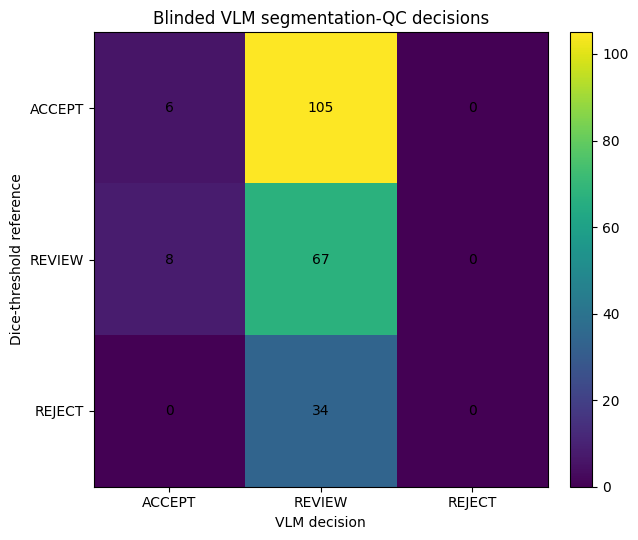

Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/02_blinded_failure_recognition_qwen25vl7b_three_class_confusion_matrix.png


In [17]:
# CELL 17 — Three-class confusion matrix
CLASS_ORDER = ["ACCEPT", "REVIEW", "REJECT"]

cm = confusion_matrix(
    valid["true_decision"],
    valid["decision"],
    labels=CLASS_ORDER
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(CLASS_ORDER)))
ax.set_yticks(np.arange(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER)
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("VLM decision")
ax.set_ylabel("Dice-threshold reference")
ax.set_title("Blinded VLM segmentation-QC decisions")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

CM_FIG = FIG_DIR / f"{EXPERIMENT_ID}_three_class_confusion_matrix.png"
plt.savefig(CM_FIG, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", CM_FIG)

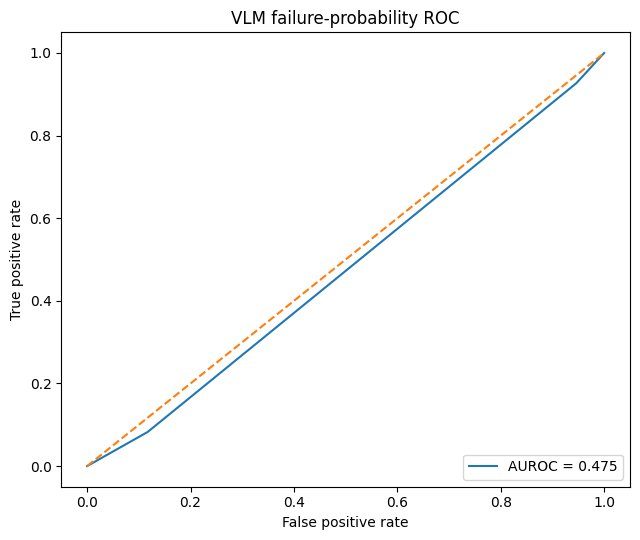

Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/02_blinded_failure_recognition_qwen25vl7b_roc.png


In [18]:
# CELL 18 — ROC curve
y_true = valid["true_failure"].astype(int).to_numpy()
score = valid["failure_score"].to_numpy()

if len(np.unique(y_true)) == 2:
    fpr, tpr, thresholds = roc_curve(y_true, score)
    auc = roc_auc_score(y_true, score)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("VLM failure-probability ROC")
    ax.legend(loc="lower right")
    plt.tight_layout()

    ROC_FIG = FIG_DIR / f"{EXPERIMENT_ID}_roc.png"
    plt.savefig(ROC_FIG, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", ROC_FIG)

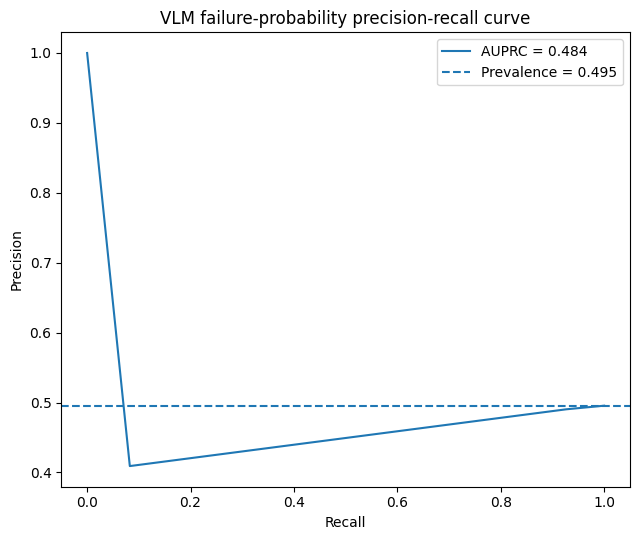

Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/02_blinded_failure_recognition_qwen25vl7b_precision_recall.png


In [19]:
# CELL 19 — Precision-recall curve
if len(np.unique(y_true)) == 2:
    precision, recall, thresholds = precision_recall_curve(y_true, score)
    ap = average_precision_score(y_true, score)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.axhline(
        y_true.mean(),
        linestyle="--",
        label=f"Prevalence = {y_true.mean():.3f}"
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("VLM failure-probability precision-recall curve")
    ax.legend(loc="best")
    plt.tight_layout()

    PR_FIG = FIG_DIR / f"{EXPERIMENT_ID}_precision_recall.png"
    plt.savefig(PR_FIG, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", PR_FIG)

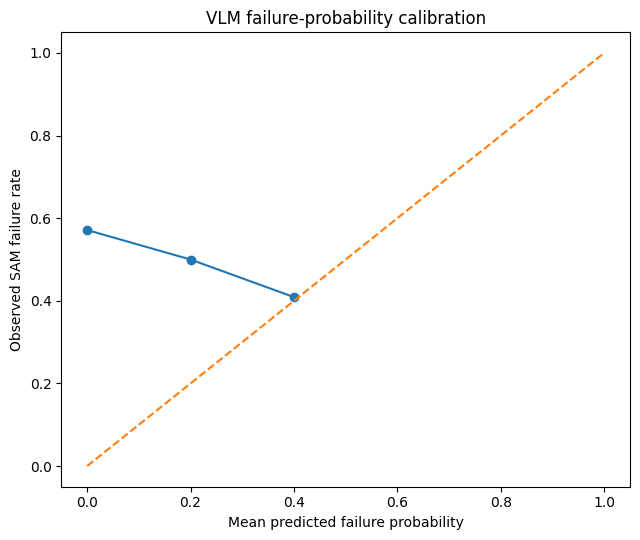

,bin_low,bin_high,n,mean_predicted_failure_probability,observed_failure_rate
0,0.0,0.1,14,0.0,0.571429
1,0.2,0.3,184,0.2,0.500000
2,0.4,0.5,22,0.4,0.409091


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_calibration_bins.csv
Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/02_blinded_failure_recognition_qwen25vl7b_calibration.png


In [20]:
# CELL 20 — Calibration analysis
def calibration_table(y, p, bins=10):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    edges = np.linspace(0, 1, bins + 1)
    rows = []

    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]

        if i == bins - 1:
            mask = (p >= lo) & (p <= hi)
        else:
            mask = (p >= lo) & (p < hi)

        if mask.sum() == 0:
            continue

        rows.append({
            "bin_low": lo,
            "bin_high": hi,
            "n": int(mask.sum()),
            "mean_predicted_failure_probability": float(p[mask].mean()),
            "observed_failure_rate": float(y[mask].mean()),
        })

    return pd.DataFrame(rows)

cal = calibration_table(y_true, score, bins=10)

CAL_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_calibration_bins.csv"
cal.to_csv(CAL_PATH, index=False)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(
    cal["mean_predicted_failure_probability"],
    cal["observed_failure_rate"],
    marker="o"
)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("Mean predicted failure probability")
ax.set_ylabel("Observed SAM failure rate")
ax.set_title("VLM failure-probability calibration")
plt.tight_layout()

CAL_FIG = FIG_DIR / f"{EXPERIMENT_ID}_calibration.png"
plt.savefig(CAL_FIG, dpi=220, bbox_inches="tight")
plt.show()

display(cal)
print("Saved:", CAL_PATH)
print("Saved:", CAL_FIG)

,n,spearman_rho_failure_probability_vs_1_minus_dice,p_value
0,220,-0.074503,0.271207


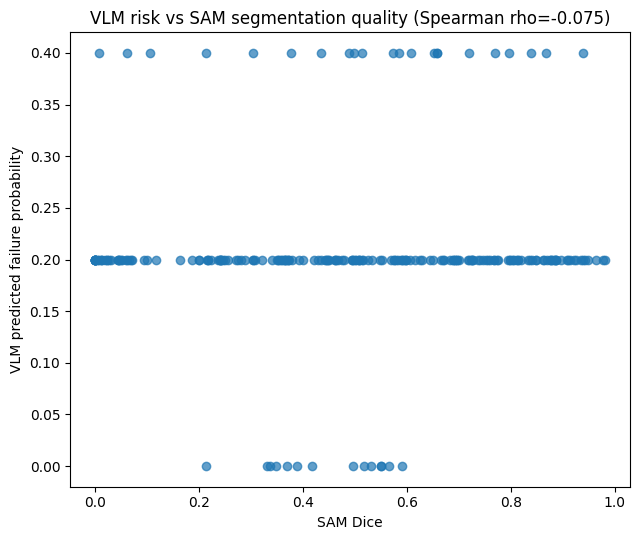

Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_risk_dice_association.csv
Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/02_blinded_failure_recognition_qwen25vl7b_failure_probability_vs_dice.png


In [21]:
# CELL 21 — Failure-probability association with segmentation quality
valid["one_minus_dice"] = 1.0 - valid["stored_dice"].astype(float)

rho, p_value = spearmanr(
    valid["failure_score"],
    valid["one_minus_dice"],
    nan_policy="omit"
)

association = pd.DataFrame([{
    "n": len(valid),
    "spearman_rho_failure_probability_vs_1_minus_dice": float(rho),
    "p_value": float(p_value),
}])

ASSOC_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_risk_dice_association.csv"
association.to_csv(ASSOC_PATH, index=False)

display(association)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(
    valid["stored_dice"],
    valid["failure_score"],
    alpha=0.7
)
ax.set_xlabel("SAM Dice")
ax.set_ylabel("VLM predicted failure probability")
ax.set_title(
    f"VLM risk vs SAM segmentation quality (Spearman rho={rho:.3f})"
)
plt.tight_layout()

SCATTER_FIG = FIG_DIR / f"{EXPERIMENT_ID}_failure_probability_vs_dice.png"
plt.savefig(SCATTER_FIG, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", ASSOC_PATH)
print("Saved:", SCATTER_FIG)

In [22]:
# CELL 22 — Error-type distribution by reference class
error_table = pd.crosstab(
    valid["error_type"],
    valid["true_decision"],
    margins=True
)

ERROR_TABLE_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_error_type_by_true_class.csv"
error_table.to_csv(ERROR_TABLE_PATH)

display(error_table)
print("Saved:", ERROR_TABLE_PATH)

true_decision,ACCEPT,REJECT,REVIEW,All
error_type,,,,
MISLOCALIZATION,105,34,67,206
NONE,6,0,8,14
All,111,34,75,220


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_error_type_by_true_class.csv


In [23]:
# CELL 23 — False reassurance and false alarm cases
false_reassurance = valid[
    (valid["true_failure"] == True) &
    (valid["pred_failure"] == False)
].copy()

false_alarm = valid[
    (valid["true_failure"] == False) &
    (valid["pred_failure"] == True)
].copy()

false_reassurance = false_reassurance.sort_values(
    ["stored_dice", "failure_score"],
    ascending=[True, True]
)

false_alarm = false_alarm.sort_values(
    ["failure_score", "stored_dice"],
    ascending=[False, False]
)

FR_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_false_reassurance_cases.csv"
FA_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_false_alarm_cases.csv"

false_reassurance.to_csv(FR_PATH, index=False)
false_alarm.to_csv(FA_PATH, index=False)

print("False reassurance cases:", len(false_reassurance))
display(
    false_reassurance[
        [
            "benchmark_id", "domain", "stored_dice",
            "decision", "failure_probability",
            "error_type", "grounding"
        ]
    ].head(20)
)

print("\nFalse alarm cases:", len(false_alarm))
display(
    false_alarm[
        [
            "benchmark_id", "domain", "stored_dice",
            "decision", "failure_probability",
            "error_type", "grounding"
        ]
    ].head(20)
)

print("Saved:", FR_PATH)
print("Saved:", FA_PATH)

False reassurance cases: 8


,benchmark_id,domain,stored_dice,decision,failure_probability,error_type,grounding
170,MR_0107,histopathology,0.213726,ACCEPT,0,NONE,The red segmentation closely follows the cell ...
29,MR_0114,histopathology,0.330617,ACCEPT,0,NONE,The red segmentation closely follows the cell ...
208,MR_0115,histopathology,0.335628,ACCEPT,0,NONE,The red segmentation closely follows the cell ...
91,MR_0117,histopathology,0.346866,ACCEPT,0,NONE,The red segmentation closely follows the cell ...
63,MR_0122,histopathology,0.369068,ACCEPT,0,NONE,The red segmentation closely follows the cell ...
22,MR_0124,histopathology,0.387604,ACCEPT,0,NONE,The red segmentation closely follows the cell ...
214,MR_0126,histopathology,0.416815,ACCEPT,0,NONE,The red segmentation closely follows the cell ...
69,MR_0130,histopathology,0.495173,ACCEPT,0,NONE,The red segmentation closely follows the cell ...



False alarm cases: 105


,benchmark_id,domain,stored_dice,decision,failure_probability,error_type,grounding
97,MR_0092,brain_mri,0.938287,REVIEW,40,MISLOCALIZATION,The red segmentation is misaligned and does no...
68,MR_0083,brain_mri,0.868139,REVIEW,40,MISLOCALIZATION,The red segmentation is misaligned and does no...
53,MR_0081,brain_mri,0.839456,REVIEW,40,MISLOCALIZATION,The red outline appears to overestimate the tu...
163,MR_0076,brain_mri,0.795875,REVIEW,40,MISLOCALIZATION,The red outline misaligns with the tumor regio...
171,MR_0074,brain_mri,0.769561,REVIEW,40,MISLOCALIZATION,The red outline misses significant tumor tissu...
78,MR_0024,brain_mri,0.719994,REVIEW,40,MISLOCALIZATION,The red segmentation oversegments the tumor re...
144,MR_0020,brain_mri,0.658294,REVIEW,40,MISLOCALIZATION,The red segmentation oversegments the tumor re...
40,MR_0019,brain_mri,0.658170,REVIEW,40,MISLOCALIZATION,The red segmentation oversegments the tumor re...
191,MR_0018,brain_mri,0.652477,REVIEW,40,MISLOCALIZATION,The red outline is misaligned with the tumor r...
6,MR_0013,brain_mri,0.607483,REVIEW,40,MISLOCALIZATION,The red outline is misaligned with the tumor r...


Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_false_reassurance_cases.csv
Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_false_alarm_cases.csv


In [24]:
# CELL 24 — Complete experiment summary
summary = {
    "experiment_id": EXPERIMENT_ID,
    "model_id": MODEL_ID,
    "model_commit": getattr(model.config, "_commit_hash", None),
    "prompt_version": PROMPT_VERSION,
    "seed": SEED,
    "generation": {
        "do_sample": False,
        "max_new_tokens": MAX_NEW_TOKENS,
        "min_pixels": MIN_PIXELS,
        "max_pixels": MAX_PIXELS,
        "dtype": "bfloat16",
    },
    "benchmark": {
        "requested_cases": int(len(inference_manifest)),
        "unique_predictions": int(len(pred)),
        "evaluable_cases": int(len(valid)),
        "parse_success_rate": float(pred["parse_ok"].mean()),
        "domains": {
            str(k): int(v)
            for k, v in valid["domain"].value_counts().to_dict().items()
        },
    },
    "reference_mapping": {
        "ACCEPT": "Dice >= 0.50",
        "REVIEW": "0.10 <= Dice < 0.50",
        "REJECT": "Dice < 0.10",
        "note": "Experimental mapping of pre-existing SAM robustness thresholds; not a clinical deployment rule."
    },
    "primary_binary_metrics": overall_binary,
    "three_class_metrics": overall_three,
    "spearman_failure_probability_vs_1_minus_dice": {
        "rho": float(rho),
        "p_value": float(p_value),
    },
    "mean_generation_seconds_per_case": float(
        pred["generation_seconds"].mean()
    ),
    "outputs": {
        "blinded_inference_manifest": str(BLINDED_MANIFEST_PATH),
        "predictions_jsonl": str(PRED_JSONL),
        "predictions_csv": str(PRED_CSV),
        "case_level_evaluation": str(EVAL_CASES_PATH),
        "domain_metrics": str(DOMAIN_METRICS_PATH),
        "bootstrap_95ci": str(BOOTSTRAP_PATH),
        "calibration_bins": str(CAL_PATH),
        "false_reassurance_cases": str(FR_PATH),
        "false_alarm_cases": str(FA_PATH),
    },
}

SUMMARY_PATH = EVAL_DIR / f"{EXPERIMENT_ID}_summary.json"
SUMMARY_PATH.write_text(json.dumps(summary, indent=2))

print("=" * 90)
print("BLINDED VLM FAILURE-RECOGNITION RESULTS")
print("=" * 90)

print(f"Evaluable cases: {len(valid)} / {len(inference_manifest)}")
print(f"Structured-output parse success: {pred['parse_ok'].mean()*100:.1f}%")
print()

print("Primary binary endpoint: Dice < 0.50")
print(f"  Balanced accuracy : {overall_binary['balanced_accuracy']:.3f}")
print(f"  Sensitivity       : {overall_binary['sensitivity_recall']:.3f}")
print(f"  Specificity       : {overall_binary['specificity']:.3f}")
print(f"  F1                : {overall_binary['f1']:.3f}")
print(f"  False reassurance : {overall_binary['false_reassurance_rate']:.3f}")
print(f"  AUROC             : {overall_binary['auroc']:.3f}")
print(f"  AUPRC             : {overall_binary['auprc']:.3f}")
print(f"  Brier score       : {overall_binary['brier']:.3f}")
print()

print("Three-class ACCEPT / REVIEW / REJECT endpoint")
print(f"  Accuracy          : {overall_three['accuracy']:.3f}")
print(f"  Macro F1          : {overall_three['macro_f1']:.3f}")
print()

print("Risk-quality association")
print(f"  Spearman rho      : {rho:.3f}")
print(f"  p-value           : {p_value:.3g}")
print()

print("Per-domain results")
display(
    domain_metrics[
        [
            "domain", "n", "balanced_accuracy",
            "sensitivity_recall", "specificity",
            "f1", "false_reassurance_rate",
            "auroc", "auprc",
            "three_class_accuracy", "three_class_macro_f1"
        ]
    ]
)

print("Summary saved:", SUMMARY_PATH)

BLINDED VLM FAILURE-RECOGNITION RESULTS
Evaluable cases: 220 / 220
Structured-output parse success: 100.0%

Primary binary endpoint: Dice < 0.50
  Balanced accuracy : 0.490
  Sensitivity       : 0.927
  Specificity       : 0.054
  F1                : 0.641
  False reassurance : 0.073
  AUROC             : 0.475
  AUPRC             : 0.484
  Brier score       : 0.345

Three-class ACCEPT / REVIEW / REJECT endpoint
  Accuracy          : 0.332
  Macro F1          : 0.191

Risk-quality association
  Spearman rho      : -0.075
  p-value           : 0.271

Per-domain results


,domain,n,balanced_accuracy,sensitivity_recall,specificity,f1,false_reassurance_rate,auroc,auprc,three_class_accuracy,three_class_macro_f1
0,brain_mri,94,0.500000,1.00,0.000000,0.637681,0.00,0.472273,0.456018,0.265957,0.140056
1,histopathology,36,0.612727,0.68,0.545455,0.723404,0.32,0.612727,0.747677,0.638889,0.401135
2,kidney_ct,90,0.500000,1.00,0.000000,0.615385,0.00,0.500000,0.444444,0.277778,0.144928


Summary saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/02_blinded_failure_recognition_qwen25vl7b_summary.json
